In [1]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import scipy
import warnings
import matplotlib

In [2]:
# write function to calculate temperature in CAMELS 

# define constant
# import astropy 

import astropy.units as u
from astropy.constants import k_B, m_p

factor = 1e10 # UnitEnergy, see https://www.tng-project.org/data/docs/faq/

def load_snap(halo):

    h = 0.6774

    f_snapshot = '/home/jovyan/Data/Sims/IllustrisTNG/L25n256/CV/CV_0/snapshot_090.hdf5'
    f_catalog  = '/home/jovyan/Data/FOF_Subfind/IllustrisTNG/L25n256/CV/CV_0/groups_090.hdf5'

    f = h5py.File(f_catalog, 'r')
    
    mgas = np.log10(f['Group/GroupMassType'][halo][0]*1e10 / h)
    r200c     = f['Group/Group_R_Crit200'][halo]
    pos_h     = f['Group/GroupPos'][:]/1e3   #Mpc/h
    len_h     = f['Group/GroupLen'][:]       #the total number of particles in the halo (gas+dm+stars+black_holes)
    lentype_h = f['Group/GroupLenType'][:]   #the number of particles in a halo by particle type

    offset = np.sum(lentype_h[:halo], axis=0)

    f = h5py.File(f_snapshot, 'r')

    start = offset[0]
    end   = offset[0]+lentype_h[halo,0]
    
    InternalEnergy = f['PartType0/InternalEnergy'][start:end] * (u.km/u.s)**2
    ElectronAbundance = f['PartType0/ElectronAbundance'][start:end] 
    position = ((f['PartType0/Coordinates'][start:end]/1e3 - pos_h[halo])*u.Mpc).to('kpc')
    mass = f['PartType0/Masses'][start:end]*1e10
    
    f.close()

    return InternalEnergy, ElectronAbundance, position, mass, r200c, mgas

    
def temp(u, xe, gamma = 5/3, Xh = 0.76):

    mu =  4 / (1 + 3*Xh + 4*Xh*xe) # mean molecular weight    
    #mu = 1.0 / (Xh * (1.0 + xe) + 0.25 * (1.0 - Xh))
    
    temp = ((gamma - 1) * mu * m_p * u/k_B).to('K')

    return temp

def temp_profile(position,halo_temp,mass,r200c):


    r = np.linalg.norm(position,axis=1) / r200c

    mean1, _, _ = scipy.stats.binned_statistic(r,halo_temp*mass,statistic=np.nansum,bins=20,range=[0,2])
    mean2, binedge, _ = scipy.stats.binned_statistic(r,mass,statistic=np.nansum,bins=20,range=[0,2])

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        mean = mean1 / mean2
    
    return np.log10(mean), binedge

In [8]:
InternalEnergy, ElectronAbundance, position, mass, r200c, mgas = load_snap(5)

halo_temp = temp(InternalEnergy, ElectronAbundance)

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def image(halo,resolution):

    InternalEnergy, ElectronAbundance, position, mass, r200c, mgas = load_snap(halo)
    halo_temp = temp(InternalEnergy, ElectronAbundance)

    x = position[:, 0].to_value('kpc')
    y = position[:, 1].to_value('kpc')
    
    temp_sum, xedges, yedges = np.histogram2d(x,y,weights=np.log10(halo_temp.value),bins=(resolution,resolution))
    count, _, _ = np.histogram2d(x,y,weights=None,bins=(resolution,resolution))
    
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    
    avg_temp = temp_sum / count
    avg_temp[count == 0] = np.nan
    
    plt.imshow(avg_temp.T,origin='lower',extent=extent,cmap='coolwarm',aspect='auto')
    
    plt.colorbar(label=r'$\langle \log T \rangle$')
    plt.xlabel('x [kpc]')
    plt.ylabel('y [kpc]')
    plt.show()

/tmp/ipykernel_123/279109616.py:18: RuntimeWarning: invalid value encountered in divide
  avg_temp = temp_sum / count


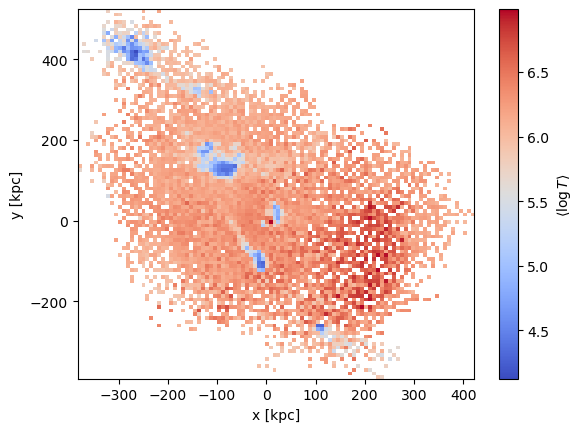

In [17]:
# generate image of given GroupNumber

image(20,resolution=100)

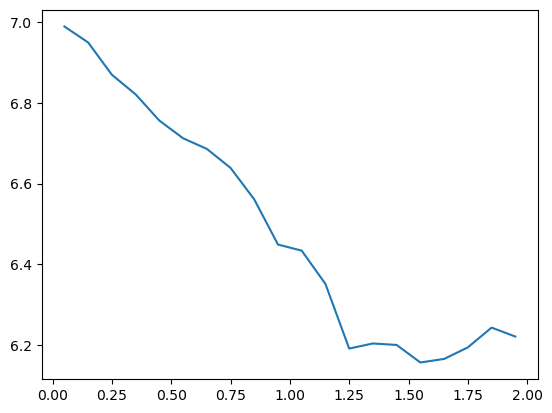

In [11]:
# generate temparature profile of given GroupNumber

mean_profile, binedge = temp_profile(position,halo_temp,mass,r200c)
binned_r = (binedge[1:]+binedge[:-1])/2

plt.plot(binned_r,mean_profile)

plt.show()

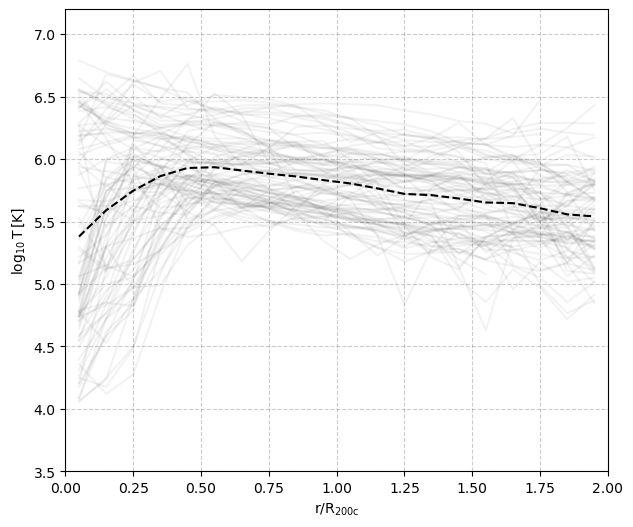

In [199]:
# iterate across a galaxy sample 

fig, ax = plt.subplots(1,1, figsize=(7, 6), sharex=True, sharey=True)

profile_all = []

for GroupNumber in np.arange(10,100):

    InternalEnergy, ElectronAbundance, position, mass, r200c = load_snap(GroupNumber)
    halo_temp = temp(InternalEnergy, ElectronAbundance)

    mean_profile, binedge = temp_profile(position,halo_temp,mass,r200c)
    binned_r = (binedge[1:]+binedge[:-1])/2

    profile_all.append(mean_profile)

    ax.plot(binned_r,mean_profile,color='black',alpha=0.05)

ax.plot(binned_r,np.nanmean(profile_all,axis=0),color='black',ls='--')

ax.set_xlim(0,2)
ax.set_ylim(3.5,7.2)

ax.set_xlabel(r'$\mathrm{r/R_{200c}}$')
ax.set_ylabel(r'$\mathrm{\log_{10} T\, [K]}$')

ax.grid(linestyle='--',color='black',alpha=0.2)

plt.show()

In [20]:
h = 0.6774

f_catalog  = '/home/jovyan/Data/FOF_Subfind/IllustrisTNG/L25n256/CV/CV_0/groups_090.hdf5'
f = h5py.File(f_catalog, 'r')
m200c = np.log10(f['Group/Group_M_Crit200'][:]*1e10 / h)
m200c = np.log10(f['Group/GroupMass'][:]*1e10 / 1)
mgas = np.log10(f['Group/GroupMassType'][:,0]*1e10 / 1)

f.close()

/tmp/ipykernel_123/153162874.py:5: RuntimeWarning: divide by zero encountered in log10
  m200c = np.log10(f['Group/Group_M_Crit200'][:]*1e10 / h)
/tmp/ipykernel_123/153162874.py:7: RuntimeWarning: divide by zero encountered in log10
  mgas = np.log10(f['Group/GroupMassType'][:,0]*1e10 / 1)


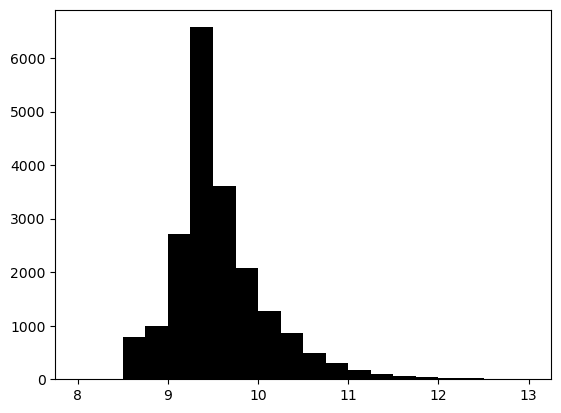

In [21]:
# plot m

plt.hist(m200c,range=[8,13],bins=20,color='black');

In [22]:
# make a mass selection 
# let's select 5 mass cuts betwene 1e8 Msun and 1e13 Msun (every order of mag.)

first_N = 100

GroupNumber_ = np.where((m200c > 10) & (m200c < np.log10(10**10.5)))[0]

GroupNumber1 = np.where((m200c > 8) & (m200c < 9))[0][:first_N]
GroupNumber2 = np.where((m200c > 9) & (m200c < 10))[0][:first_N]
GroupNumber3 = np.where((m200c > 10) & (m200c < 11))[0][:first_N]
GroupNumber4 = np.where((m200c > 11) & (m200c < 12))[0][:first_N]
GroupNumber5 = np.where((m200c > 12) & (m200c < 13))[0][:first_N]

/tmp/ipykernel_69/3526830385.py:20: RuntimeWarning: divide by zero encountered in log10
  mgas = np.log10(f['Group/GroupMassType'][halo][0]*1e10 / h)
/tmp/ipykernel_69/3526830385.py:20: RuntimeWarning: divide by zero encountered in log10
  mgas = np.log10(f['Group/GroupMassType'][halo][0]*1e10 / h)


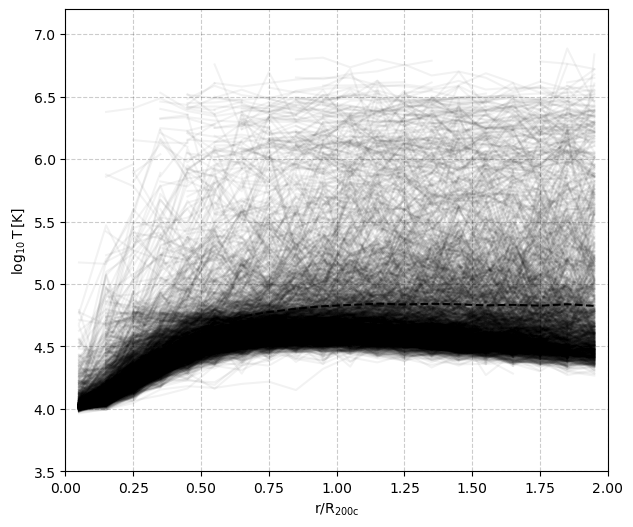

In [53]:
# iterate across a galaxy sample 

fig, ax = plt.subplots(1,1, figsize=(7, 6), sharex=True, sharey=True)

for mass_selection in [GroupNumber_]:

    profile_all = []

    for GroupNumber in mass_selection:

        InternalEnergy, ElectronAbundance, position, mass, r200c, mgas = load_snap(GroupNumber)
        halo_temp = temp(InternalEnergy, ElectronAbundance)

        if r200c == 0.:
            continue
    
        mean_profile, binedge = temp_profile(position,halo_temp,mass,r200c)
        binned_r = (binedge[1:]+binedge[:-1])/2
    
        profile_all.append(mean_profile)

        ax.plot(binned_r,mean_profile,color='black',ls='-',alpha=0.05)

    ax.plot(binned_r,np.nanmean(profile_all,axis=0),color='black',ls='--')

ax.set_xlim(0,2)
ax.set_ylim(3.5,7.2)

ax.set_xlabel(r'$\mathrm{r/R_{200c}}$')
ax.set_ylabel(r'$\mathrm{\log_{10} T\, [K]}$')

ax.grid(linestyle='--',color='black',alpha=0.2)

plt.show()

In [79]:
# create code to plot image + temperature profile

def image_v2(halo,resolution):

    fig, ax = plt.subplots(1,2, figsize=(7*2, 6), sharex=False, sharey=False)

    InternalEnergy, ElectronAbundance, position, mass, r200c, mgas = load_snap(halo)
    halo_temp = temp(InternalEnergy, ElectronAbundance)

    x = position[:, 0].to_value('kpc')
    y = position[:, 1].to_value('kpc')
    
    temp_sum, xedges, yedges = np.histogram2d(x,y,weights=np.log10(halo_temp.value),bins=(resolution,resolution))
    count, _, _ = np.histogram2d(x,y,weights=None,bins=(resolution,resolution))
    
    extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
    
    avg_temp = temp_sum / count
    avg_temp[count == 0] = np.nan
    
    im = ax[0].imshow(avg_temp.T,origin='lower',extent=extent,cmap='coolwarm',aspect='auto')
    
    fig.colorbar(im, ax=ax[0], label=r'$\langle \log T \rangle$')
    ax[0].set_xlabel('x [kpc]')
    ax[0].set_ylabel('y [kpc]')
    
    if r200c == 0.:
        print('no r200 for this group')
    
    mean_profile, binedge = temp_profile(position,halo_temp,mass,r200c)
    binned_r = (binedge[1:]+binedge[:-1])/2
        
    ax[1].plot(binned_r,mean_profile,color='black',ls='-',alpha=1)
    
    
    ax[1].set_xlim(0,2)
    ax[1].set_ylim(3.5,7.2)
    
    ax[1].set_xlabel(r'$\mathrm{r/R_{200c}}$')
    ax[1].set_ylabel(r'$\mathrm{\log_{10} T\, [K]}$')
    
    ax[1].grid(linestyle='--',color='black',alpha=0.2)
    
    plt.show()

/tmp/ipykernel_123/1660450915.py:18: RuntimeWarning: invalid value encountered in divide
  avg_temp = temp_sum / count


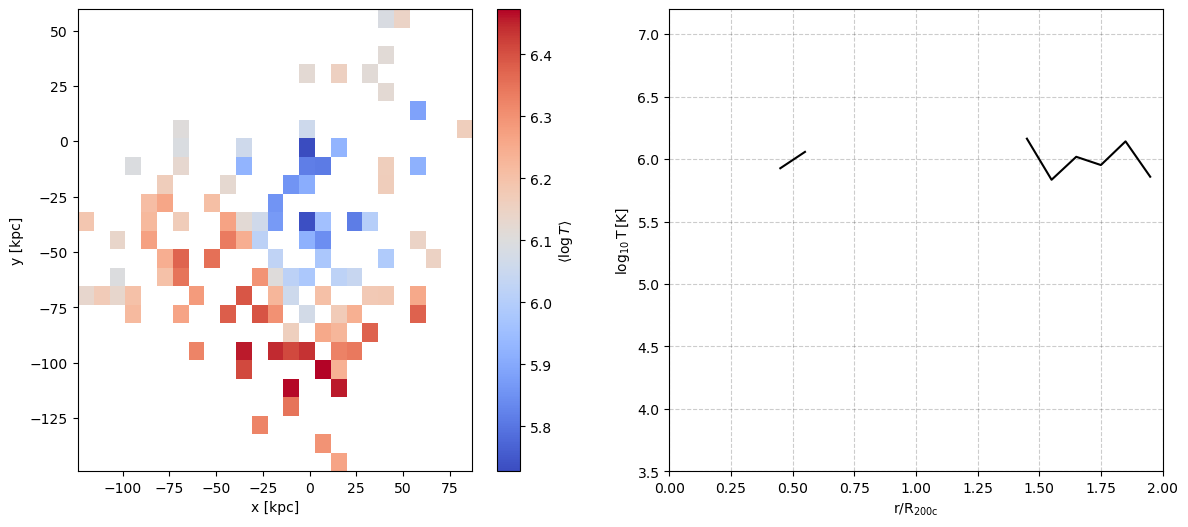

In [85]:
# determine halos with odd temperature profile 
# here we generate an image of a random ~1e10 halo

GroupNumber_random = np.random.randint(0,len(GroupNumber_))
image_v2(GroupNumber_random,resolution=25)

In [41]:
GroupNumber_

array([1063, 1064, 1085, ..., 3806, 3812, 3813])

In [34]:
np.random.randint(0,len(GroupNumber_))

325